# Top Model Decision Tree

### ⚠️ Google Colab GPU Only Notebook

This notebook is designed to run in **Google Colab with GPU**. To start using this notebook, clone this GitHub repo in Colab:
```
!git clone https://github.com/Lynnicia/CryoEM_membranes_top_model_decision_tree.git
```
✅ It requires:
- GPU runtime (CUDA) for speed tests
- Linux environment
- Colab-specific install steps (e.g., `!pip install`, `!git clone`, `from google.colab.patches import cv2_imshow`)

❌ Running locally (especially on Windows) may fail due to:
- Detectron2 installation issues
- CUDA/toolchain mismatches
- Missing compiled operators
                            
![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)
(https://colab.research.google.com/github/Lynnicia/CryoEM_membranes_top_model_decision_tree/blob/main/top_model_decision_tree.ipynb)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content
!git clone https://github.com/Lynnicia/CryoEM_membranes_top_model_decision_tree.git

/content
Cloning into 'CryoEM_membranes_top_model_decision_tree'...
remote: Enumerating objects: 634, done.
remote: Counting objects: 100% (184/184), done.
remote: Compressing objects: 100% (145/145), done.
remote: Total 634 (delta 124), reused 37 (delta 37), pack-reused 450 (from 2)
Receiving objects: 100% (634/634), 186.88 MiB | 39.63 MiB/s, done.
Resolving deltas: 100% (238/238), done.


##Step 1. Load in models and test images

### 🌱 Prepare notebook for model seeds and model architectures 🌱

### Load in LD and ULD best model checkpoints into notebook:

In [3]:
%cd /content/CryoEM_membranes_top_model_decision_tree/seed/models
%run /content/CryoEM_membranes_top_model_decision_tree/seed/models/model_repo.ipynb


/content/CryoEM_membranes_top_model_decision_tree/seed/models
--2026-04-11 20:48:51--  https://github.com/Lynnicia/CryoEM_membranes_top_model_decision_tree/releases/download/640-YOLOv11-LD/640-YOLOv11-LD.pt
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1139374969/f4ed4f74-7d85-4f96-90c3-863cd464393d?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-11T21%3A38%3A49Z&rscd=attachment%3B+filename%3D640-YOLOv11-LD.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-11T20%3A38%3A37Z&ske=2026-04-11T21%3A38%3A49Z&sks=b&skv=2018-11-09&sig=xBVzE21NNl1eX0RUAz0glpcy9rPDnlnTnMoa9oryDoQ%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia

 ```
          @@@@@@@@@@@@@@@@@@@@@
       @@@@@@@@@@@@@@@@@@@@@@@@@@@
    @@                             @@
  @@    @@@@@  @@@@@  @@@@@  @@@     @@
 @@    @       @      @      @  @     @@
 @@    @@@@@   @@@    @@@    @   @    @@
 @@         @  @      @      @   @    @@
  @@   @@@@@   @@@@@  @@@@@  @@@@    @@
   @@                              @@
      @@@@@@@@@@@@@@@@@@@@@@@@@@@@
         @@@@@@@@@@@@@@@@@@@@@@
```
### Load in LD and ULD model seeds into notebook:

In [4]:
%cd /content/CryoEM_membranes_top_model_decision_tree

from seed import LD_models, ULD_models
from seed.LD_models import MODEL_MAP as LD_MODEL_MAP
from seed.ULD_models import MODEL_MAP as ULD_MODEL_MAP

MODEL_MAP = {
    **LD_MODEL_MAP,
    **ULD_MODEL_MAP,
}

print(MODEL_MAP)

/content/CryoEM_membranes_top_model_decision_tree
{('LD', 640): <function model_LD_640 at 0x7d825bae9940>, ('LD', 1024): <function model_LD_1024 at 0x7d825bae9a80>, ('ULD', 640): <function model_ULD_640 at 0x7d825bae96c0>, ('ULD', 1024): <function model_ULD_1024 at 0x7d825bae9bc0>}



### Load in model architectures into notebook:
This code run will load in YOLOv11, YOLO26, U-Net, Detectron2 and SAM3 fine-tuned pre-trained models

In [5]:
#If the session restarts, re-run the module
%cd /content/CryoEM_membranes_top_model_decision_tree
%run /content/CryoEM_membranes_top_model_decision_tree/seed/model_arch.ipynb

/content/CryoEM_membranes_top_model_decision_tree
Loading YOLOv11 and YOLO26...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ YOLOv11 and YOLO26 model architectures loaded
Loading U-Net...
✓ U-Net architecture loaded
Loading Detectron2...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.2/274.2 kB 16.6 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while ge

### 💧 Prepare Notebook for Test Images💧

### Drop in test images into notebook:

What test images do you have? Select dose and image size

Dose: ("LD", "ULD")

Image Size: (640, 1024)   640 is for speed, 1024 is for detail

In [6]:
test_electron_dose_decision = "LD"      # options: "LD", "ULD"

test_image_size_decision = 1024      # options: 640, 1024 (no quotes!)



Input if this is a custom dataset. If so, add path, text (needed for YOLO) and json (needed for COCO)

In [7]:
#OPTIONAL CUSTOM IMAGES, SKIP IF NOT USING A CUSTOM DATASET (test folder including images and optinoally a single .json file)

custom_dataset = "NO"        # default "NO". If using a custom dataset, type "YES"

custom_dataset_folder = "/content/my_custom_dataset/test"

custom_dataset_text = "/content/my_custom_dataset/test/test.txt"      # YOLO only

custom_dataset_json =  "/content/my_custom_dataset/test/_annotations.coco.json"      # COCO only



#Do not touch below!~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


%cd /content/CryoEM_membranes_top_model_decision_tree

#from drop import drop_test_images
from drop.coco_bacteria_dataset import CocoBacteriaDataset
from torch.utils.data import DataLoader
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.data.datasets import register_coco_instances

if custom_dataset == "YES":
    from drop import custom_test_images

import pandas as pd
import numpy as np
import cv2
import glob
import os
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from pycocotools.coco import COCO
from PIL import Image
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

if custom_dataset == "NO":
    from drop import LD_test_images, ULD_test_images
    from drop.LD_test_images import TEST_MAP as LD_TEST_MAP
    from drop.ULD_test_images import TEST_MAP as ULD_TEST_MAP

    TEST_MAP = {
        **LD_TEST_MAP,
        **ULD_TEST_MAP,
    }

    print(TEST_MAP)

if custom_dataset == "YES":
    from drop import LD_custom_test_images, ULD_custom_test_images
    from drop.LD_custom_test_images import TEST_MAP as LD_TEST_MAP
    from drop.ULD_custom_test_images import TEST_MAP as ULD_TEST_MAP

    TEST_MAP = {
        **LD_TEST_MAP,
        **ULD_TEST_MAP,
    }

    print(TEST_MAP)



#--------------------

test_loader, test_image_dir, test_images_yv11, test_images_y26, test_img_folder, test_ann_path = TEST_MAP[(test_electron_dose_decision, test_image_size_decision)]()



/content/CryoEM_membranes_top_model_decision_tree
{('LD', 640): <function test_image_LD_640 at 0x7d80ead2c0e0>, ('LD', 1024): <function test_image_LD_1024 at 0x7d80ead2c180>, ('ULD', 640): <function test_image_ULD_640 at 0x7d80ead2c540>, ('ULD', 1024): <function test_image_ULD_1024 at 0x7d80ead2c5e0>}
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!




```
# LD - Instantiate the model and run unbiased test evaluation for curves

#
#                               %%%%%%%
#                        %%%%%%%%%%%%%%%%%
#                       %%%%%%%%%%%%%%%%%%%%%%%
#                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#                  %%%%%|     |%%/   \%%|   \%%%%%%%%
#                 %%%%%%%%| |%%%| |%| |%| *_/%%%%%%%
#                %%%%%%%%%| |%%%%\   /%%| |%%%%%%%
#                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#                    %%%%%%%%%%%\%%|%%/%%%%%%%%%
#                         %%%%   \|||/  %%%%
#                                 |||
#                                 |||
#                                 |||
#                                 |||
#                              ___|||___
#  ######################## __//  |||  \\___ #######################
"""#################### // |Tree Root START| \\ ####################"""
"""################## // ######## ||| ######## \\ ##################"""
```



##Step 2. Select mask count

##### How many bacteria are in your test images? Manually count your test images and input the count below:

(20 count is for LD test images and 65 count for ULD images)

Then, run mask prediction below:

Pick LD model set, ULD model set or both for the predictions:

("LD", "ULD")

In [14]:
manual_count = 20

In [25]:
model_electron_dose_decision = "LD"      # options: "LD", "ULD"


import importlib
from root import LD_mask_decision_tree_d2

importlib.reload(LD_mask_decision_tree_d2)

#Do not touch below!~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

results_folder = "/content/CryoEM_membranes_top_model_decision_tree/Masks"
os.makedirs(results_folder, exist_ok=True)


model_image_size_decision = 640     # (no quotes!)
MODEL_PATH_u, MODEL_PATH_yv11, MODEL_PATH_y26, MODEL_PATH_d2, MODEL_PATH_s3 = MODEL_MAP[(model_electron_dose_decision, model_image_size_decision)]()

if model_electron_dose_decision == "LD":
    Model_Image_Size = model_image_size_decision
    Model_Electron_Dose = model_electron_dose_decision
    Test_Image_Size = test_image_size_decision
    Test_Electron_Dose = test_electron_dose_decision
    input_folder = test_img_folder
    TARGET_FOLDER = results_folder
    # YOLOv11
    # YOLO26
    # U-Net
    # Detectron2
    from root.LD_mask_decision_tree_d2 import run_model_pipeline_d2
    Model = f"{model_image_size_decision}-Detectron2"
    run_model_pipeline_d2(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_d2, test_img_folder)

    #SAM3

"""elif model_electron_dose_decision == "ULD":
    from root import ULD_mask_decision_tree

else:
    raise ValueError("Invalid option: choose 'LD' or 'ULD'")

model_image_size_decision = 1024     # (no quotes!)
MODEL_PATH_u, MODEL_PATH_yv11, MODEL_PATH_y26, MODEL_PATH_d2, MODEL_PATH_s3 = MODEL_MAP[(model_electron_dose_decision, model_image_size_decision)]()

if model_electron_dose_decision == "LD":
    from root import LD_mask_decision_tree

elif model_electron_dose_decision == "ULD":
    from root import ULD_mask_decision_tree

else:
    raise ValueError("Invalid option: choose 'LD' or 'ULD'")"""

[04/11 21:10:31 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/CryoEM_membranes_top_model_decision_tree/seed/models/640-Detectron2-LD.pth ...
/content/CryoEM_membranes_top_model_decision_tree/Datasets/LD/COCO/test/1024/Camera-Falcon-0301-Falcon_dyn_png.rf.5bf811eb9a7489116326786e4cc4f702.jpg: 1 bacteria
/content/CryoEM_membranes_top_model_decision_tree/Datasets/LD/COCO/test/1024/Camera-Falcon-0301-Falcon_dyn_png.rf.5bf811eb9a7489116326786e4cc4f702.jpg: 2 bacteria
/content/CryoEM_membranes_top_model_decision_tree/Datasets/LD/COCO/test/1024/88_Camera-Falcon-1942-Falcon_MOPSsuc_dyn_png.rf.729f3d05251f3d8f6a2724f0234b55d6.jpg: 3 bacteria
/content/CryoEM_membranes_top_model_decision_tree/Datasets/LD/COCO/test/1024/88_Camera-Falcon-1942-Falcon_MOPSsuc_dyn_png.rf.729f3d05251f3d8f6a2724f0234b55d6.jpg: 4 bacteria
/content/CryoEM_membranes_top_model_decision_tree/Datasets/LD/COCO/test/1024/57_Camera-Falcon-2313-0002-Falcon_MOPSsuc_dyn_png.rf.6bcbd9febff04c985d

'elif model_electron_dose_decision == "ULD":\n    from root import ULD_mask_decision_tree\n\nelse:\n    raise ValueError("Invalid option: choose \'LD\' or \'ULD\'")\n\nmodel_image_size_decision = 1024     # (no quotes!)\nMODEL_PATH_u, MODEL_PATH_yv11, MODEL_PATH_y26, MODEL_PATH_d2, MODEL_PATH_s3 = MODEL_MAP[(model_electron_dose_decision, model_image_size_decision)]()\n\nif model_electron_dose_decision == "LD":\n    from root import LD_mask_decision_tree\n\nelif model_electron_dose_decision == "ULD":\n    from root import ULD_mask_decision_tree\n\nelse:\n    raise ValueError("Invalid option: choose \'LD\' or \'ULD\'")'

Plot model predicted bacteria count against manual count:

/tmp/ipykernel_11535/3534711780.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


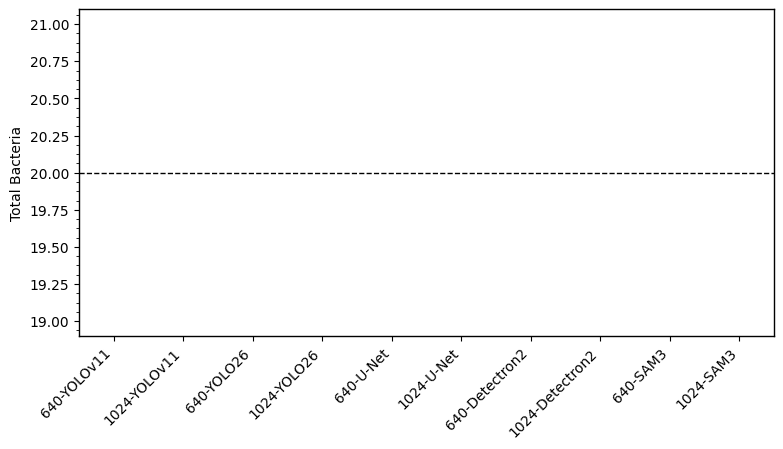

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

csv_path = "/content/CryoEM_membranes_top_model_decision_tree/top_model_table.csv"
df = pd.read_csv(csv_path)

dfs_ld = df[
    (df["Test_Electron_Dose"] == "LD") &
    (df["Test_Image_Size"] == 1024)
]
color_map = {
    "U-Net": "grey",
    "YOLOv11": "blue",
    "YOLO26": "purple",
    "Detectron2": "green",
    "SAM3": "orange"
}

g = sns.catplot(
    data=dfs_ld,
    kind="bar",
    x="Model",
    y="total_bacteria",
    hue="Model_Architecture",
    palette=color_map,
    errorbar=None,
    height=4,
    aspect=2,
    legend=False
)

for ax in g.axes.flat:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

g.set_axis_labels("", "Total Bacteria")

from matplotlib.ticker import AutoMinorLocator

for ax in g.axes.flat:
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))  # 2 minor ticks between majors
    ax.tick_params(axis='x', which='minor', length=3)

for ax in g.axes.flat:
    ax.axhline(manual_count, color='black', linestyle='--', linewidth=1)
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.show()

Set folder and predict masks:

In [ ]:
os.makedirs("/content/CryoEM_membranes_top_model_decision_tree/Masks", exist_ok=True)

TARGET_FOLDER = "/content/CryoEM_membranes_top_model_decision_tree/Masks"

%run root_mask_decision_tree.py


Prepare speed test (clear GPU cache)

metrics

speed